# Ch.00 — Overview: Constrained dealers & PIM taxonomy

**Paper:** Huang–Ranaldo–Schrimpf–Somogyi (Nov 2021, SSRN 3960577) — *Constrained Dealers and Market Efficiency*  
**NOTES:** [`NOTES.md`](NOTES.md) (§1, PDF pp. 2–7) · **SoT:** [`../../CHAPTER_INDEX.md`](../../CHAPTER_INDEX.md)

Core claim: when dealers’ risk-bearing capacity is tight, **liquidity elasticity weakens** and **PIM** (price inefficiency) rises. Desk maps CLS FX triplets → cross-venue ETH LOP on **HL + Deribit** real quotes (+ Kraken **spot_l2** when dense; `trade_synth` **QUARANTINED**) and DCM → public PC1 proxies — **never** soft-Promote TOB-cross as arb α.


In [1]:
from pathlib import Path
import json, os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BOOK = Path(os.environ.get("ARES_MICROSTRUCTURE") or (Path.home() / "srv" / "ares-microstructure")) / "research" / "books" / "cd_me"
OUT = BOOK / "out"
SCRIPTS = BOOK / "scripts"
ROOT = BOOK.parents[2]  # ares-microstructure repo root (research.lib absolute imports)
sys.path.insert(0, str(SCRIPTS))
sys.path.insert(0, str(ROOT))
from _nb_common import (
    load_json, expand_pim_hourly, expand_dcm_hourly, day_summary_table, SIGNAL_BOARD,
    load_kraken_inventory, kraken_mode_for_day,
)
from certified_panel import load_certified, primary_days, spot_l2_days
from research.lib import cdme  # noqa: E402

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

def show_pngs(fig_dir: Path, pattern="*.png"):
    if not fig_dir.is_dir():
        print("no figs dir", fig_dir)
        return
    for p in sorted(fig_dir.glob(pattern)):
        display(Markdown(f"**{p.name}** — `{p.relative_to(BOOK)}`"))
        display(Image(filename=str(p)))

def print_board(rows=None):
    rows = rows or SIGNAL_BOARD
    print(f"{'id':34s} {'gate':6s} note")
    print("-" * 88)
    for i, g, n in rows:
        print(f"{i:34s} {g:6s} {n}")

PASS2 = OUT / "pass2"
KR_INV = load_kraken_inventory(BOOK)
CERT = load_certified()
PRIMARY = primary_days(CERT)
SPOT = spot_l2_days(CERT)
print("BOOK", BOOK)
print("certified primary n=", len(PRIMARY), PRIMARY)
print("spot_l2 subpanel n=", len(SPOT), SPOT)
print("pass2 present", PASS2.is_dir(), "falsifiers", (PASS2 / "pass2_falsifiers.json").is_file())
print("trade_synth QUARANTINED — never primary")


BOOK /home/dev/srv/ares-microstructure/research/books/cd_me
certified primary n= 9 ['2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17', '2026-09-18', '2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01']
spot_l2 subpanel n= 4 ['2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01']
pass2 present True falsifiers True
trade_synth QUARANTINED — never primary


## Crypto map vs paper objects

| Paper | Desk |
|-------|------|
| Triangular LOP / VLOOP | `|log(mid_i/mid_j)|` on latency-aligned TOB (HL↔DB; +KR spot_l2) |
| TCOST | Sum of relative half-spreads on arb legs |
| PIM = VLOOP + |TCOST| when VLOOP>0 | `cdme.pim_from_components` |
| DCM (VaR/CDS/…) | PC1 of |funding|, |basis|, RV, imbalance — **Kill** bank vanity |
| Elasticity corr(VLM, PIM) | Hourly notional × PIM, DCM quantile split |
| Kraken leg | Dense **spot_l2** only; else **2-venue**; `trade_synth` QUARANTINED |


In [2]:

pim = load_json(OUT / "pim_vloop_tcost" / "summary.json")
dcm = load_json(OUT / "dcm_proxies" / "summary.json")
el = load_json(OUT / "elasticity_regimes" / "summary.json")
kr = load_json(OUT / "kraken_probe.json")
p2 = load_json(PASS2 / "pass2_falsifiers.json")
print("PIM days", None if not pim else pim.get("days"), "n_ok", None if not pim else pim.get("n_ok"),
      "venues", None if not pim else pim.get("venues"))
print("DCM n_ok", None if not dcm else dcm.get("n_ok"))
if el:
    pooled = (el.get("pooled") or {}).get("all") or {}
    print("elasticity pooled", {k: pooled.get(k) for k in ("n", "corr", "ci_lo", "ci_hi")})
print("Kraken probe keys", None if not kr else list(kr.keys()))
if p2:
    pp = p2.get("pim_panel") or {}
    print("certified primary", PRIMARY, "spot_l2", SPOT)
    print("pass2 n_ok", pp.get("n_days_ok"),
          "promote_count", (p2.get("decisions") or {}).get("promote_count"))


PIM days ['2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17', '2026-09-18', '2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01'] n_ok 9 venues ['hyperliquid', 'deribit', 'kraken']
DCM n_ok 9
elasticity pooled {'n': 88, 'corr': -0.4612833556222188, 'ci_lo': -0.5697748432382688, 'ci_hi': -0.35269499514070435}
Kraken probe keys ['futures_pf', 'spot']
certified primary ['2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17', '2026-09-18', '2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01'] spot_l2 ['2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01']
pass2 n_ok 9 promote_count 0


## Pass-2 scoreboard snapshot


,day,ok,venues,n_venues,n_finite,pim_mean,vloop_mean,tcost_mean,corr_vt,cov_hl,cov_db,cov_kr,kraken
0,2026-09-14,True,"hyperliquid,deribit",2,668,0.0156,0.0070,0.0044,0.8308,0.0425,0.4933,NaN,absent_2venue
1,2026-09-15,True,"hyperliquid,deribit",2,165,0.0210,0.0109,0.0030,1.0000,0.0437,0.4901,NaN,absent_2venue
2,2026-09-16,True,"hyperliquid,deribit",2,621,0.0118,0.0061,0.0039,0.9938,0.0427,0.4731,NaN,absent_2venue
3,2026-09-17,True,"hyperliquid,deribit",2,582,0.0124,0.0061,0.0033,0.9428,0.0427,0.4964,NaN,absent_2venue
4,2026-09-18,True,"hyperliquid,deribit",2,717,0.0133,0.0070,0.0045,0.9946,0.0439,0.4851,NaN,absent_2venue
5,2026-09-25,True,"hyperliquid,deribit,kraken",3,1876,0.0282,0.0139,0.0052,0.9090,0.0431,0.4845,0.0982,spot_l2
6,2026-09-26,True,"hyperliquid,deribit,kraken",3,1863,0.0357,0.0179,0.0090,0.9020,0.0434,0.4996,0.1252,spot_l2
7,2026-09-27,True,"hyperliquid,deribit,kraken",3,914,0.0321,0.0153,0.0084,0.8448,0.0434,0.4999,0.0112,spot_l2
8,2026-10-01,True,"hyperliquid,deribit,kraken",3,1502,0.0469,0.0232,0.0071,0.9098,0.0437,0.4024,0.0571,spot_l2


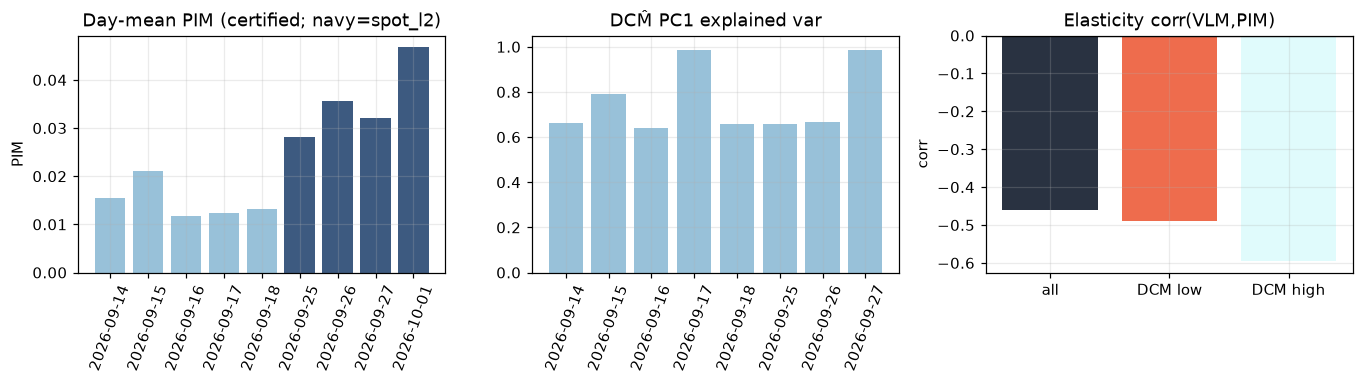

kraken modes: {'absent_2venue': 5, 'spot_l2': 4}


In [3]:

pim_panel = load_json(OUT / "pim_vloop_tcost" / "panel_rows.json") or []
tbl = day_summary_table(pim_panel, inventory=KR_INV)
display(tbl.round(4))

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))
ax = axes[0]
ok = tbl[tbl["ok"] == True]
colors = ["#3d5a80" if str(m) == "spot_l2" else "#98c1d9" for m in ok["kraken"]]
ax.bar(ok["day"], ok["pim_mean"], color=colors)
ax.tick_params(axis="x", rotation=70)
ax.set_title("Day-mean PIM (certified; navy=spot_l2)")
ax.set_ylabel("PIM")

ax = axes[1]
dcm_rows = (dcm or {}).get("day_summaries") or []
days, expl = [], []
for r in dcm_rows:
    d = r.get("dcm") or {}
    if d.get("explained_var") is not None and (d.get("n_valid") or 0) > 0:
        days.append(r["day"]); expl.append(d["explained_var"])
ax.bar(days, expl, color="#98c1d9")
ax.tick_params(axis="x", rotation=70)
ax.set_ylim(0, 1.05)
ax.set_title("DCM̂ PC1 explained var")

ax = axes[2]
pooled = ((el or {}).get("pooled") or {})
allc = pooled.get("all") or {}
reg = pooled.get("regime_point") or {}
labels = ["all", "DCM low", "DCM high"]
vals = [allc.get("corr"), reg.get("corr_low"), reg.get("corr_high")]
ax.bar(labels, [v if v is not None else np.nan for v in vals], color=["#293241", "#ee6c4d", "#e0fbfc"])
ax.axhline(0, color="k", lw=0.8)
ax.set_title("Elasticity corr(VLM,PIM)")
ax.set_ylabel("corr")
plt.tight_layout()
plt.show()
print("kraken modes:", tbl["kraken"].value_counts().to_dict())


## Reading order

1. `pim_vloop_tcost` — construct VLOOP/TCOST/PIM (certified 2-venue / spot_l2)  
2. `dcm_proxies` — public DCM̂  
3. `elasticity_regimes` — regime corr  
4. `lstar_panel` / `model_sim` — **park**  
5. `robustness` — Pass-2 falsifiers (`out/pass2/`)  
6. `paper_shadow` — living monitor (`live_orders=false`)

Chapter notebooks live beside NOTES under `chapters/<pkg>/`. Desk rollup: [`../../notebooks/desk_synthesis.ipynb`](../../notebooks/desk_synthesis.ipynb).


## Signal board


In [4]:

print_board()
if PASS2.is_dir():
    p2 = load_json(PASS2 / "pass2_falsifiers.json") or {}
    print("\nPass-2 decisions:", json.dumps(p2.get("decisions"), indent=2))
else:
    print("\nFalsifier status: out/pass2/ missing — run scripts/exp_pass2_falsifiers.py")


id                                 gate   note
----------------------------------------------------------------------------------------
risk.pim_cross_venue               Hold   PIM = VLOOP+|TCOST| · panel_core_2venue (HL↔Deribit real quotes); spot_l2 subpanel only
info.vloop_tcost_commonality       Hold   pooled hourly corr on certified real-quote panel (see DESK_MEMO)
info.vloop_tcost_stress_split      Hold   calm vs stress (PIM q25/q75) on certified panel
risk.dcm_pc1                       Hold   PC1 of public funding/basis/RV/imbalance proxies
info.pim_dcm_incremental           Hold   partial(PIM,DCM|RV) on certified panel — not pure RV alias
liq.elasticity_regime              Hold   corr(VLM,PIM) by DCM quantile — certified 2-venue; ceiling Hold
info.elasticity_after_rv           Hold   partial(PIM,VLM|RV) on certified panel
info.object_leadlag_map            Hold   hourly lead-lag vs mid_ret/RV/notional — descriptive map not α
info.kraken_spot_vs_2venue         Hold   spot_l2 sub